In [69]:
from collections import defaultdict

import pandas as pd
pd.options.display.float_format = '{:>5.2f}'.format
import numpy as np

import matplotlib.pyplot as plt
import json
from pprint import pprint

from scipy.ndimage.filters import gaussian_filter1d

In [319]:
filename = "log/output.log"
metrics = ['mrr', 'hit1', 'hit3', 'hit10']

Conjunction_queries = ['1p', '2p', '3p', '2i', '3i', 'ip', 'pi']
Negation_queries = ['2in', '3in', 'inp', 'pin', 'pni']
Disjunction_queries = ['2u', 'up', '2u-dnf', 'up-dnf']
queries = Conjunction_queries + Negation_queries + Disjunction_queries

filter_width = .1

In [71]:
def read_log_lines(filename):
    lines = []
    with open(filename, 'rt') as f:
        for line in f.readlines():
            lines.append(line)
    return lines

def filter_lines(lines, key_str):
    rec = []
    for line in lines:
        if not key_str in line:
            continue
        json_content = json.loads(line.split(']')[-1])
        try:
            rec.append(
                json_content
            )
        except:
            print("Error in ", line)
    return rec 

In [259]:
def plot_train_lines():
    rec = filter_lines(lines=lines, key_str="learn")
    if not rec:
        return
    data = defaultdict(list)
    for i, this_record in enumerate(rec):
        for k in this_record:
            data[k].append(this_record[k])
        data['id'].append(i)
    df = pd.DataFrame(data)

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(7, 3))

    ax1.set_xlabel('steps')
    ax1.set_ylabel('truth value')

    keys = ['pos_tv', 'neg_tv', 'tv']
    for label in keys:
        if label in df.columns:
            ax1.plot(df['id'], gaussian_filter1d(df[label], filter_width), label=label)
    # ax1.plot(df['id'], gaussian_filter1d(df['pos_tv'] - df['neg_tv'], filter_width), label='pos - neg', color='purple', alpha=0.5)
    ax1.axhline(y=0.5, color='r', linestyle='-')
    ax1.legend()
    # ax1.set_yscale('log')


    ax2.set_xlabel('steps')
    ax2.set_ylabel('loss')

    keys = ['pos_nll', 'neg_nll', 'loss']
    for label in keys:
        ax2.plot(df['id'], gaussian_filter1d(df[label], filter_width), label=label)
        
    acc_loss = []
    ax2.legend()
    # ax2.set_yscale('log')
    # ax2.set_yticks([1e-2, 1e-1, 1])
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()


def plot_evaluation(scope=['train', 'validate', 'test']):
    all_rec = filter_lines(lines=lines, key_str="evaluate")

    
    for k in queries:        
        if not any(k in rec for rec in all_rec): continue
        fig, axes = plt.subplots(ncols=len(scope), figsize=(3 * len(scope) + 1, 3))
        
        if len(scope) == 1:
            axes = [axes]

        for ax, desc in zip(axes, scope):
            rec = filter_lines(lines=lines, key_str=f"evaluate {desc}")
            if not rec: continue
            if k not in rec[0]: continue

            data = defaultdict(list)
            for i, this_record in enumerate(rec):
                for k1 in this_record[k]:
                    data[k1].append(this_record[k][k1])
                data['id'].append(i)

            df = pd.DataFrame(data)

            ax.set_xlabel('epoch')
            ax.set_ylabel('score')
            ax.set_title(f'{desc} scores for query {k}')

            for label in metrics:
                if len(df['id']) == 1:
                    ax.scatter(df['id'], df[label] * 100, label=label)
                else:
                    ax.plot(df['id'], df[label] * 100, label=label)
            ax.legend()
            # ax.set_ylim([0, 1])

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        plt.show()

In [299]:
def evaluation_to_tables(line, verbose=True):
    data = defaultdict(list)
    for m in ['mrr']:
        for k in queries:
            if k in line:
                data[k].append(line[k][m] * 100)
    df = pd.DataFrame(data)
    try:
        df['epfo mean'] = df[Conjunction_queries + Disjunction_queries].mean(axis=1)
    except:
        pass
    try:
        df['Neg mean'] = df[Negation_queries].mean(axis=1)
    except:
        pass    
    return df

def aggregate_evaluations(scope=['valid', 'test']):
    for desc in scope:
        print(desc)
        rec_lines = filter_lines(lines, key_str=f"evaluate {desc}")
        df_list = []
        for e, line in enumerate(rec_lines):
            df = evaluation_to_tables(line)
            # print(df.to_markdown(floatfmt=".2f"))
            df['epoch'] = e
            df_list.append(df)
        final_df = pd.concat(df_list)
        final_df = final_df.reindex()
        print(final_df.to_markdown(floatfmt=".1f", index=False))
        

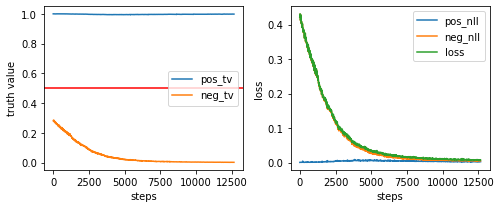

valid
|   1p |   2p |   3p |   2i |   3i |   ip |   pi |   2in |   3in |   inp |   pin |   pni |   2u |   up |   2u-dnf |   up-dnf |   epfo mean |   Neg mean |   epoch |
|-----:|-----:|-----:|-----:|-----:|-----:|-----:|------:|------:|------:|------:|------:|-----:|-----:|---------:|---------:|------------:|-----------:|--------:|
| 44.7 |  8.6 |  5.2 | 19.9 | 28.2 | 10.5 | 10.1 |   0.1 |   0.1 |   6.0 |   0.1 |   1.1 | 11.3 |  6.6 |     11.2 |      0.0 |        14.2 |        1.5 |     0.0 |
| 43.6 |  8.1 |  4.6 | 21.3 | 30.5 | 10.2 | 11.5 |   0.2 |   0.3 |   5.7 |   0.2 |   1.7 | 11.1 |  6.4 |     11.1 |      0.0 |        14.4 |        1.6 |     1.0 |
| 41.2 |  7.3 |  4.0 | 22.4 | 31.5 |  9.6 | 13.6 |   0.7 |   0.8 |   5.2 |   0.3 |   2.4 | 10.9 |  5.9 |     10.8 |      0.0 |        14.3 |        1.9 |     2.0 |
| 39.4 |  6.7 |  3.5 | 22.7 | 31.3 |  9.1 | 15.3 |   1.3 |   1.8 |   4.9 |   0.4 |   2.7 | 10.6 |  5.5 |     10.6 |      0.0 |        14.0 |        2.3 |     3.0 |
| 39.9 |  

In [314]:
lines = read_log_lines('log/train_query_boosting_1p/output.log')
plot_train_lines()
# plot_evaluation(scope=['valid', 'test'])
aggregate_evaluations()

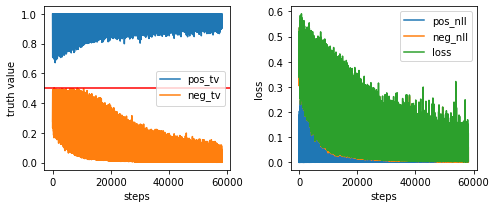

valid
|   1p |   2p |   3p |   2i |   3i |   ip |   pi |   2in |   3in |   inp |   pin |   pni |   2u |   up |   2u-dnf |   up-dnf |   epfo mean |   Neg mean |   epoch |
|-----:|-----:|-----:|-----:|-----:|-----:|-----:|------:|------:|------:|------:|------:|-----:|-----:|---------:|---------:|------------:|-----------:|--------:|
| 39.1 |  7.2 |  4.0 | 20.2 | 27.4 |  9.5 | 12.1 |   1.1 |   1.3 |   5.3 |   0.8 |   2.0 | 10.5 |  5.5 |     10.5 |      0.0 |        13.3 |        2.1 |     0.0 |
| 39.6 |  6.6 |  3.4 | 20.2 | 27.0 |  9.0 | 13.2 |   2.6 |   3.5 |   4.9 |   1.3 |   3.1 | 10.4 |  4.9 |     10.4 |      0.0 |        13.2 |        3.1 |     1.0 |
| 39.9 |  6.1 |  3.2 | 20.4 | 28.0 |  8.4 | 13.4 |   3.4 |   4.9 |   4.7 |   1.5 |   3.8 | 10.3 |  4.5 |     10.3 |      0.0 |        13.1 |        3.7 |     2.0 |
| 40.3 |  5.9 |  3.0 | 20.6 | 29.2 |  7.9 | 13.8 |   4.0 |   5.7 |   4.6 |   1.8 |   4.2 | 10.2 |  4.3 |     10.2 |      0.0 |        13.2 |        4.1 |     3.0 |
| 40.7 |  

In [324]:
lines = read_log_lines('log/train_query_boosting_1p2p/output.log')
plot_train_lines()
# plot_evaluation(scope=['valid', 'test'])
aggregate_evaluations()

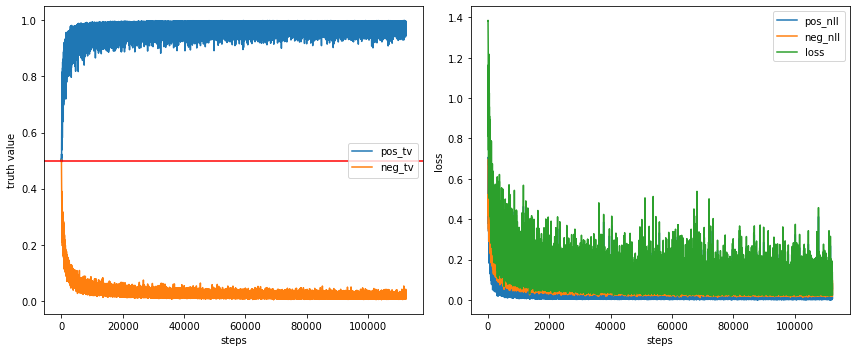

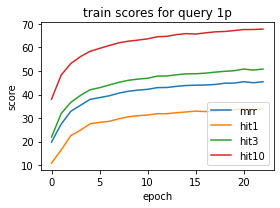

In [252]:
lines = read_log_lines('log/test_plus/output.log')
plot_train_lines()
plot_evaluation(scope=['train'])